# LangGraph Supervisor Demo

Acest notebook demonstrează implementarea unui sistem multi-agent folosind biblioteca `langgraph` și modelul `llama3-8b-8192` de la Groq. Sistemul este configurat pentru a rezolva o sarcină de cercetare și generare de raport, utilizând agenți specializați (`researcher`, `analyst`, `condition`, `write_one`, `write_more`, `editing`) și un supervisor care controlează fluxul execuției pe baza unor condiții.

Fluxul complet este: `research → analyze → condition → [write_one | write_more] → edit → END`

O caracteristică cheie este mecanismul **Human-in-the-Loop** implementat prin `interrupt()` în nodul de editare — execuția grafului este întreruptă pentru a permite intervenția umană înainte de a produce raportul final. Starea este persistată între apeluri cu ajutorul `MemorySaver`, iar execuția este reluată prin `Command(resume=...)`.

Scopul este de a ilustra cum se pot crea grafuri de agenți flexibile, cu ramuri condiționale și puncte de control umane, pentru automatizarea sarcinilor complexe.


### Instalarea Bibliotecilor Necesare

Această celulă instalează bibliotecile `langgraph` și `langchain-google-genai`, esențiale pentru construirea și rularea grafului de agenți, precum și pentru interacțiunea cu modelele Gemini de la Google. Este o etapă pregătitoare obligatorie înainte de a rula codul principal.

In [6]:
import sys
!pip install langgraph langchain-google-genai langchain-groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.5 MB/s eta 0:00:00


### Definirea și Execuția Sistemului Multi-Agent (LangGraph)

Această celulă conține implementarea completă a sistemului multi-agent folosind `langgraph`. Sunt definite:

*   **`State`**: O structură de date (`TypedDict`) cu câmpurile stării partajate: `task`, `research`, `analysis`, `condition`, `write_one`, `write_more`, `editing`, `report`.
*   **`llm`**: Modelul `openai/gpt-oss-20b` inițializat cu `ChatGroq`, cu `temperature=0` pentru răspunsuri deterministe. Cheia API este preluată din Google Colab `userdata`.
*   **Funcțiile Agenților** (noduri în graf):
    *   `researcher` — caută informații despre sarcina primită
    *   `analyst` — analizează rezultatele cercetării și extrage insights
    *   `condition` — extrage un singur număr din analiză, folosit de supervisor pentru decizie
    *   `write_one` — generează un raport scurt (~10 cuvinte)
    *   `write_more` — generează un raport detaliat (~20 cuvinte)
    *   `editing` — implementează **Human-in-the-Loop** prin `interrupt()`: execuția grafului se oprește și așteaptă input uman; raportul final este cel furnizat de utilizator la reluare
*   **`supervisor`**: Logică de rutare condițională — dacă `condition == 1` trimite spre `write_one`, altfel spre `write_more`.
*   **`MemorySaver`**: Checkpointer care persistă starea grafului între apeluri, necesar pentru a putea relua execuția după `interrupt()`.
*   **Construirea `workflow`**: Noduri, punct de intrare (`research`), muchii fixe și o muchie condițională de la `condition` via `supervisor`.
*   **Execuția în două etape**:
    1. `graph.invoke(...)` — pornește execuția cu sarcina `"Câte luni are Jupiter?"` și se oprește la `interrupt()`
    2. `graph.invoke(Command(resume=...))` — reia execuția cu inputul uman și produce `report`-ul final


In [10]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Literal
from google.colab import userdata
from langgraph.types import Command, interrupt

class State(TypedDict):
    task: str
    research: str
    analysis: str
    condition: str
    write_one: str
    write_more: str
    editing: str
    report: str

# GROQ_API_KEY poate fi luată accesând link-ul https://console.groq.com/keys
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    groq_api_key=userdata.get("GROQ_API_KEY"),
    temperature=0,
)

# AGENȚI
def researcher(state):
    result = llm.invoke(f"Caută informații despre: {state['task']}")
    print("✓ Researcher done")
    return {"research": result.content}

def analyst(state):
    result = llm.invoke(f"Analizează și extrage insights: {state['research']}")
    print("✓ Analyst done")
    return {"analysis": result.content}

def condition(state):
    result = llm.invoke(f"Extrage un singur număr din următorul text: {state['analysis']}. Răspunde doar cu numărul.")
    print("✓ Condition done")
    return {"condition": result.content}

def write_one(state):
    result = llm.invoke(f"Scrie raport în limba română care să conțină rezultatul (10 cuvinte): {state["analysis"]} după următorul format: - Titlu: - Data de azi: - Rezultat:")
    print("✓ Writer one done")
    return {"write_one": result.content}

def write_more(state):
    result = llm.invoke(f"Scrie raport în limba română care să conțină rezultatul (20 cuvinte): {state["analysis"]} după următorul format: - Titlu: - Data de azi: - Rezultat:")
    print("✓ Writer more done")
    return {"write_more": result.content}

def editing(state):
    updated = interrupt({"instruction": "Editează următorul raport pentru a fi mai clar și concis: ",
                        "value": f"{state['write_one'] if state['write_one'] else state['write_more']}"})
    return {"report": updated}

# SUPERVISOR
def supervisor(state) -> Literal["research", "analyze", "condition", "write_one", "write_more", "edit", "end"]:
    if not state.get("condition"):
        return "condition"
    elif int(state.get("condition")) == 1:
        return "write_one"
    elif int(state.get("condition")) > 1:
        return "write_more"
    else:
        return "end"

# GRAPH
workflow = StateGraph(State)
workflow.add_node("research", researcher)
workflow.add_node("analyze", analyst)
workflow.add_node("condition", condition)
workflow.add_node("write_one", write_one)
workflow.add_node("write_more", write_more)
workflow.add_node("edit", editing)

workflow.set_entry_point("research")

workflow.add_edge("research", "analyze")
workflow.add_edge("analyze", "condition")

workflow.add_conditional_edges(
    "condition",
    supervisor,
    {"write_one": "write_one", "write_more": "write_more", "end": END}
)

workflow.add_edge("write_one", "edit")
workflow.add_edge("write_more", "edit")
workflow.add_edge("edit", END)

chekpointer = MemorySaver()

graph = workflow.compile(checkpointer=chekpointer)

config = {"configurable": {"thread_id": "123"}}

# EXECUTARE
print("🚀 Research Team Start\n")
initial = graph.invoke(
    {
    "task": "Câte luni are Jupiter?",
    "research": "",
    "analysis": "",
    "condition": "",
    "write_one": "",
    "write_more": "",
    "editing": "",
    "report": ""
    }, config=config
)

interrupt_data = initial["__interrupt__"][0].value
print("\n⏸️  INTERRUPT - Editare necesară:")
print("-" * 60)
print(f"📌 {interrupt_data['instruction']}")
print(f"\n{interrupt_data['value']}")


🚀 Research Team Start

✓ Researcher done
✓ Analyst done
✓ Condition done
✓ Writer more done

⏸️  INTERRUPT - Editare necesară:
------------------------------------------------------------
📌 Editează următorul raport pentru a fi mai clar și concis: 

- **Titlu:** Raport privind numărul de luni ale lui Jupiter  
- **Data de azi:** 31 martie 2026  
- **Rezultat:** Jupiter are 79 de luni confirmate în 2023, patru mari dominante, rest sub 200 km, descoperiri continuă să crească numărul.


In [11]:
final = graph.invoke(
    Command(resume="""<YOUR_EDITED_REPORT_HERE>"""),
    config=config
)

print("\n📄 RAPORT FINAL:")
print("="*60)
print(final["report"])


📄 RAPORT FINAL:
- **Titlu:** Raport privind numărul de luni ale lui Jupiter  
- **Data de azi:** 31 martie 2026  
- **Rezultat:** Jupiter are 79 de luni confirmate în 2023, patru mari dominante, rest sub 200 km, descoperiri continuă să crească numărul...


### Vizualizarea Structurii Grafului

Această celulă utilizează biblioteca `IPython.display` pentru a genera și afișa o reprezentare vizuală a grafului construit. Imaginea, generată în format Mermaid PNG, ajută la înțelegerea clară a nodurilor (agenților) și a muchiilor (tranzițiilor) dintre ele, ilustrând fluxul de execuție al sistemului multi-agent.

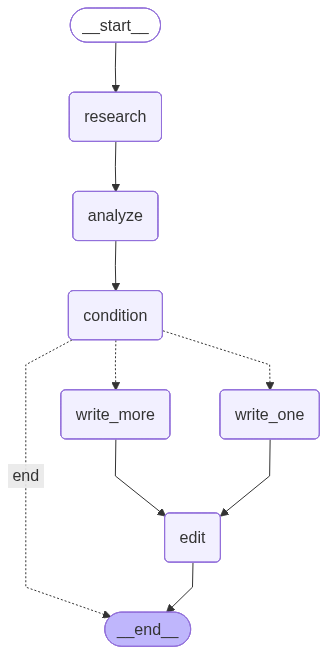

In [12]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())